# Example on the TreeAI Database

In this notebook we illustrate the basic usage of deepforest-modal-app with the [TreeAI Global Initiative dataset](https://zenodo.org/records/15351054):

1. **Pre-trained tree crown inference**: predict tree crowns using [the DeepForest pre-trained model](https://deepforest.readthedocs.io/en/v2.0.0/user_guide/02_prebuilt.html#tree-crown-detection-model)
2. **Fine-tune the tree crown model** on the TreeAI annotations
3. **Fine-tuned inference and evaluation**: run inference with the fine-tuned model and compare results

For advanced topics (custom configuration, loggers, callbacks) see [`treeai-advanced.ipynb`](treeai-advanced.ipynb). For multi-species classification with the crop model see [`treeai-crop-model.ipynb`](treeai-crop-model.ipynb).

## 0. Setup

Let us start with some imports:

In [ ]:
import time
from os import path

import matplotlib.pyplot as plt
import pandas as pd

import deepforest_modal_app as dma
import treeai_utils
from deepforest_modal_app import eval_utils, plot_utils

Additionally, we will define some analysis parameters. We will be using the "12_RGB_ObjDet_640_fL" dataset of the Tree AI Database [2]. In order to run the notebook, you will need to set `base_dir` as the path to the "12_RGB_ObjDet_640_fL" directory of the Tree AI dataset. You can follow the instructions [in the Zenodo repository](https://zenodo.org/records/15351054) to obtain the data.

We will focus on three target species: the Norway spruce (*Picea abies*), Scots pine (*Pinus sylvestris*) and European beech (*Fagus sylvatica*).

In [ ]:
# path to the Tree AI dataset
base_dir = "treeai-data/12_RGB_ObjDet_640_fL"

# to name folders in the modal volumes
dataset_id = "12_RGB_ObjDet_640_fL"

# target species
target_species = ["picea abies", "pinus sylvestris", "fagus sylvatica"]

# viz args
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

# for reproducibility
random_state = 0

### Processing the TreeAI annotations into geo-data frames

We'll now run the code below to get our training and validation annotations as geo-data frames following the DeepForest format:

In [ ]:
# load TreeAI dataset
train_gdf, train_img_dir, _ = treeai_utils.get_annot_gdf(
    base_dir, which="train", species=target_species
)
val_gdf, val_img_dir, _ = treeai_utils.get_annot_gdf(
    base_dir, which="val", species=target_species
)

# output fine-tuned model checkpoint
fine_tuned_filepath = path.join(dataset_id, "crown-fine-tune.pl")

# ensure that annotations are strictly larger than 1 px
# see also https://github.com/weecology/DeepForest/pull/1285
train_gdf = treeai_utils.ensure_gt_1px(train_gdf)
val_gdf = treeai_utils.ensure_gt_1px(val_gdf)

# since each image has a unique file name, we will use a single remote directory for all
# images (train and validation)
remote_img_dir = dataset_id

val_img_filenames = val_gdf["image_path"].unique()
# show the validation data frame
val_gdf.head()

100%|███████████████████████████████████████████████████████| 303/303 [00:04<00:00, 67.02it/s]


,label,image_path,xmin,ymin,xmax,ymax,geometry
80,1,000000000324.png,436.00032,599.00032,527.00000,640.00000,"POLYGON ((527 599, 527 640, 436 640, 436 599, ..."
81,1,000000000324.png,617.99968,620.00000,639.99968,640.00000,"POLYGON ((640 620, 640 640, 618 640, 618 620, ..."
82,1,000000000324.png,608.00000,555.99968,640.00000,613.99968,"POLYGON ((640 556, 640 614, 608 614, 608 556, ..."
83,1,000000000324.png,524.99968,559.00032,620.99968,640.00000,"POLYGON ((621 559, 621 640, 525 640, 525 559, ..."
84,17,000000000324.png,584.00000,275.00000,640.00000,397.00000,"POLYGON ((640 275, 640 397, 584 397, 584 275, ..."


### Uploading the required data (images) to a Modal storage volume

Now we will start using Modal, more precisely, uploading (if they have not been uploaded already) the required images to a storage volume (by default named `"deepforest-data"`). Note that this already requires [setting up your Modal user account](https://modal.com/docs/guide/modal-user-account-setup) (which you will only need to do once). Since installing deepforest-modal-app will also install the modal Python package, you will just need to run `modal setup` from the command line.

Once the Modal account is set up, we can run the cell below to upload the images using the `ensure_imgs` function, which takes a local directory as first argument and uploads all its images to the storage volume (in the directory specified by the `remote_img_dir` keyword argument):

In [ ]:
# upload (if needed) train and validation images (to the same folder)
for img_dir in [train_img_dir, val_img_dir]:
    dma.ensure_imgs(
        img_dir,
        remote_img_dir=remote_img_dir,
    )

## 1. Inference with the pre-trained DeepForest tree crown model

Once the required images are already in the storage volume, we can run an "ephemeral" DeepForest Modal app to perform inference with the fine-tuned model. To that end, we can use the [`dma.app.run`](https://modal.com/docs/guide/apps) method as a context manager and then run the `predict` function, which takes the image file names, the path to the remote folder in the storage volume and forwards the rest of keyword arguments to [the DeepForest `predict_tile` function](https://deepforest.readthedocs.io/en/v2.1.0/user_guide/16_prediction.html#predict-a-tile-using-model-predict-tile), e.g., the intersection over union (IoU) threshold to consider that two bounding boxes are "match":

In [ ]:
# # run inference
# with modal.enable_output():
# run ephemeral app
with dma.app.run():
    _start = time.perf_counter()
    pt_pred_gdf = dma.predict.remote(
        img_filenames=val_img_filenames,
        remote_img_dir=remote_img_dir,
    )
    print(
        f"Pre-trained inference predicted {len(val_img_filenames)} tiles in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Pre-trained inference predicted 145 tiles in 37.9s


After running inference (in the "ephemeral" GPU-enabled app), we will get the results locally as a geo-data frame:

In [ ]:
pt_pred_gdf.head()

,xmin,ymin,xmax,ymax,label,score,image_path,geometry
0,306.0,164.0,422.0,282.0,Tree,0.273658,000000000324.png,"POLYGON ((422 164, 422 282, 306 282, 306 164, ..."
1,1.0,491.0,46.0,593.0,Tree,0.269762,000000000324.png,"POLYGON ((46 491, 46 593, 1 593, 1 491, 46 491))"
2,90.0,151.0,215.0,271.0,Tree,0.266192,000000000324.png,"POLYGON ((215 151, 215 271, 90 271, 90 151, 21..."
3,195.0,90.0,296.0,193.0,Tree,0.227980,000000000324.png,"POLYGON ((296 90, 296 193, 195 193, 195 90, 29..."
4,310.0,489.0,412.0,586.0,Tree,0.226232,000000000324.png,"POLYGON ((412 489, 412 586, 310 586, 310 489, ..."


### Evaluate the pre-trained tree crown predictions, locally

We can now evaluate the predictions of the pre-trained model *locally* - we are just comparing geo-data frames, there is absolutely no need for a GPU-enabled server:

/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


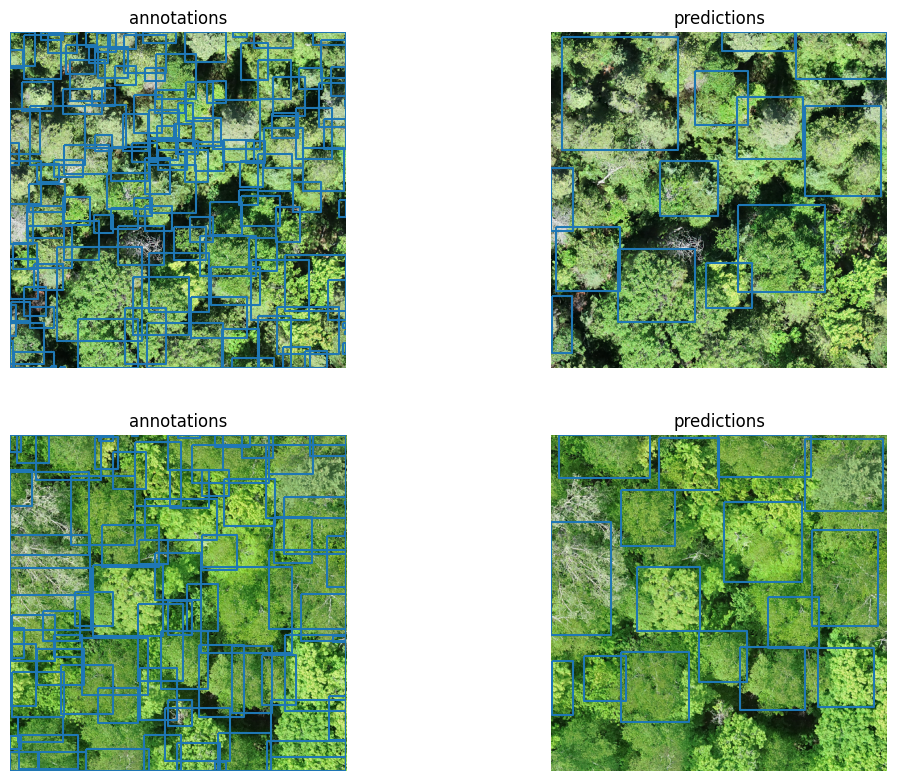

In [ ]:
# plot only a tiny sample of images
n_plot_imgs = 2
plot_img_filenames = pd.Series(val_img_filenames).sample(
    n_plot_imgs, random_state=random_state
)
fig = plot_utils.plot_annot_vs_pred(
    pt_pred_gdf[pt_pred_gdf["image_path"].isin(plot_img_filenames)],
    val_gdf[val_gdf["image_path"].isin(plot_img_filenames)],
    val_img_dir,
    # since we are only predicting tree crowns, do not use any color code and do not add
    # any legend
    plot_pred_kwargs={"legend": False, "column": None},
    plot_annot_kwargs={"legend": False, "column": None},
)

As we can see, there is much room for improvement. We can better quantify the visual impressions by computing (again, *locally*) the precision (proportion of predicted objects that have a ground truth positive match - *for a given IoU threshold*) and recall (proportion of ground truth objects that have a true positive match - *for a given IoU threshold*):

In [ ]:
# # ignore species since the pre-trained model only predicts crowns
# crown_label_dict = {"Tree": 0}
crown_annot_gdf = val_gdf.assign(**{"label": "Tree"})

# evaluate results
eval_iou_threshold = 0.4  # deepforest defaults
pt_eval_results = eval_utils.evaluate_geometry(
    pt_pred_gdf,
    crown_annot_gdf,
    eval_iou_threshold,  # crown_label_dict
)
# eval_results["results"]
box_precision = float(pt_eval_results["box_precision"])
box_recall = float(pt_eval_results["box_recall"])
box_f1 = (
    0.0
    if (box_precision + box_recall) == 0
    else 2 * box_precision * box_recall / (box_precision + box_recall)
)
print(
    f"Evaluation metrics at IoU >= {eval_iou_threshold:.2f}\n"
    f"box_precision: {box_precision:.4f}\n"
    f"box_recall:    {box_recall:.4f}\n"
    f"box_f1:        {box_f1:.4f}"
)

Evaluation metrics at IoU >= 0.40
box_precision: 0.6284
box_recall:    0.1367
box_f1:        0.2245


## 2. Fine-tuning the tree crown detection model

We can fine-tune the pre-trained model with the training annotations using `retrain_crown_model`.

The resulting checkpoint is saved to the **persistent storage volume** so it survives the ephemeral app and can be used in later runs. If the checkpoint already exists (from a previous run), pass `retrain_if_exists=True` to overwrite it.

For custom training configuration, loggers and callbacks see [`treeai-advanced.ipynb`](treeai-advanced.ipynb).

In [ ]:
with dma.app.run():
    _start = time.perf_counter()
    dma.retrain_crown_model.remote(
        train_gdf.assign(**{"label": "Tree"}),
        remote_img_dir,
        test_df=val_gdf.assign(**{"label": "Tree"}),
        dst_filepath=fine_tuned_filepath,
        retrain_if_exists=True,
    )
    print(
        "Fine-tuned crown model training completed in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Fine-tuned crown model training completed in 1002.0s


We can now run inference with the fine-tuned model by using again the `predict` function but passing the path to the fine-tuned model checkpoint as the `checkpoint_filepath` keyword argument:

In [ ]:
with dma.app.run():
    # predict with the fine-tuned model
    _start = time.perf_counter()
    ft_pred_gdf = dma.predict.remote(
        img_filenames=val_img_filenames,
        remote_img_dir=remote_img_dir,
        checkpoint_filepath=fine_tuned_filepath,
    )
    print(
        f"Fine-tuned inference predicted {len(val_img_filenames)} tiles in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Fine-tuned inference predicted 145 tiles in 37.7s


### Evaluate the fine-tuned tree crown predictions, locally

Again, once we have performed fine-tuning and inference on a GPU-enabled ephemeral Modal app, we can evaluate the predictions locally:

/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/home/martibosch/libraries/deepforest-modal-app/.pixi/envs/user-guide/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


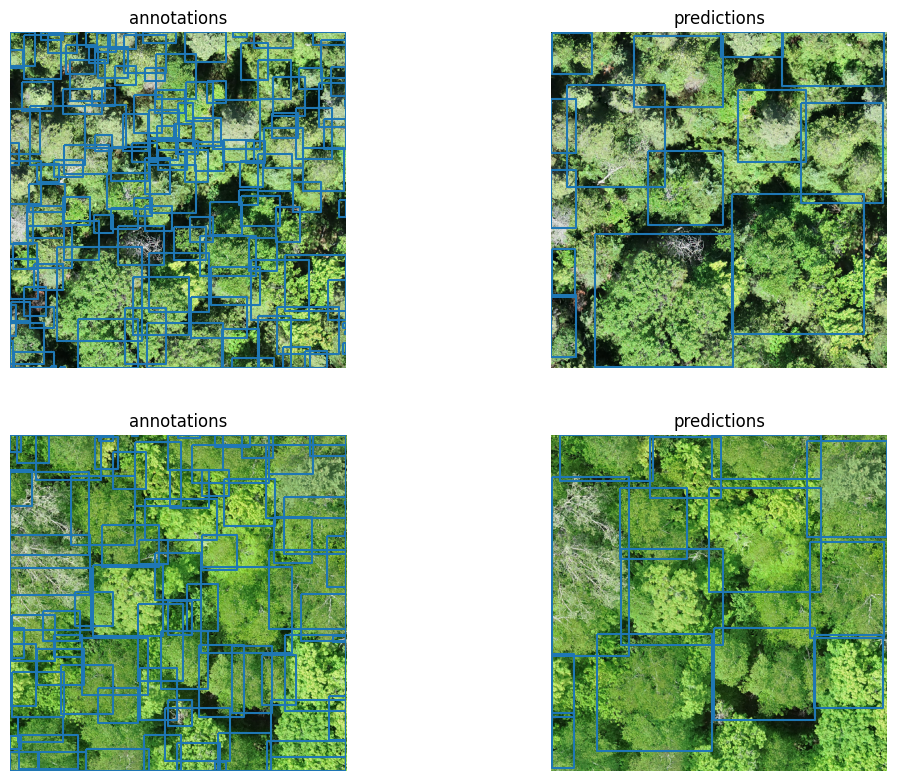

In [ ]:
fig = plot_utils.plot_annot_vs_pred(
    ft_pred_gdf[ft_pred_gdf["image_path"].isin(plot_img_filenames)],
    crown_annot_gdf[crown_annot_gdf["image_path"].isin(plot_img_filenames)],
    val_img_dir,
    # since we are only predicting tree crowns, do not use any color code and do not add
    # any legend
    plot_pred_kwargs={"legend": False, "column": None},
    plot_annot_kwargs={"legend": False, "column": None},
)

The fine-tuning does not seem to have improved the tree crown predictions, but let us again confirm this with the precision and recall metrics:

In [ ]:
ft_eval_results = eval_utils.evaluate_geometry(
    ft_pred_gdf,
    crown_annot_gdf,
    eval_iou_threshold,  # crown_label_dict
)
# eval_results["results"]
box_precision = float(ft_eval_results["box_precision"])
box_recall = float(ft_eval_results["box_recall"])
box_f1 = (
    0.0
    if (box_precision + box_recall) == 0
    else 2 * box_precision * box_recall / (box_precision + box_recall)
)
print(
    f"Evaluation metrics at IoU >= {eval_iou_threshold:.2f}\n"
    f"box_precision: {box_precision:.4f}\n"
    f"box_recall:    {box_recall:.4f}\n"
    f"box_f1:        {box_f1:.4f}"
)

Evaluation metrics at IoU >= 0.40
box_precision: 0.5073
box_recall:    0.1076
box_f1:        0.1776


Not only fine-tuning **on the training set** did not improve the evaluation metrics **for the validation set**, but it actually made them worse (both the precision and recall).

## References

1. Weinstein, B. G., Marconi, S., Aubry‐Kientz, M., Vincent, G., Senyondo, H., & White, E. P. (2020). DeepForest: A Python package for RGB deep learning tree crown delineation. Methods in Ecology and Evolution, 11(12), 1743-1751.
2. Beloiu Schwenke, M., Xia, Z., Novoselova, I., Gessler, A., Kattenborn, T., Mosig, C., Puliti, S., Waser, L., Rehush, N., Cheng, Y., Xinliang, L., Griess, V. C., & Mokroš, M. (2025). TreeAI Global Initiative - Advancing tree species identification from aerial images with deep learning (TreeAI.V1.2) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.15351054